In [139]:
# import the ReddditProcess class python script that are based on the RedditProcessing class python script,
#  but also add additional funcitons
from RedditProcess import RedditProcess

# importing packages and nltk data libraries
import string
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
from matplotlib.dates import DateFormatter

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer



# Before Text Preprocessing

Codes below are constructed by myself.

In [140]:
# Input file of reddit posts
redditFile = 'reddit_posts.json'

# Read and process the JSON file
with open(redditFile, 'r') as f:
    SubredditData = json.load(f)
    
# Get top 5 submissions by score (the number of upvotes for the submission)
top_n=5
submissions = SubredditData.get('submissions', [])

# Sort submissions by score in descending order
sorted_submissions = sorted(
    submissions,
    key=lambda sub: sub.get('score', 0),
    reverse=True)

# Get the top N submissions
top_submissions = sorted_submissions[:top_n]

print(f"--- Top 5 Submissions by Score ---")
for i, sub in enumerate(top_submissions):
    score = sub.get('score', 'N/A')
    title = sub.get('title', 'N/A')
    timestamp = sub.get('created')

    # Convert timestamp to date and time format
    try:
        if timestamp is not None:
            date_str = pd.to_datetime(timestamp, unit='s').strftime('%Y-%m-%d %H:%M:%S')
        else:
            date_str = "N/A"
    except (ValueError, TypeError) as e:
        print(f"Error: Could not convert timestamp for title '{title}': {e}") # Print out the error message

    print(f"Rank {i+1}:")
    print(f"  Score: {score}")
    print(f"  Date:  {date_str}")
    print(f"  Title: {title}\n")

--- Top 5 Submissions by Score ---
Rank 1:
  Score: 1266
  Date:  2025-03-08 07:15:30
  Title: UAE gets 0 stars from me

Rank 2:
  Score: 1063
  Date:  2025-03-29 03:18:55
  Title: Vietnam probably has the best value for your money in the world right now

Rank 3:
  Score: 769
  Date:  2025-03-24 18:12:40
  Title: Built the tool I wish existed when I started traveling - 5,698 cities, monthly Airbnb data, 100% free

Rank 4:
  Score: 527
  Date:  2025-03-31 03:36:40
  Title: First Thoughts After Returning From 5 Months in South America

Rank 5:
  Score: 463
  Date:  2025-04-01 16:40:56
  Title: If you want to move abroad, find a remote job first



In [141]:
submissions[:1]

[{'title': 'Latin America vs Eastern Europe',
  'author': 'LiftSleepRepeat123',
  'content': 'These are the two sweetspots for me, due to the lower cost of living in both places combined with cultures that I find at least somewhat interesting. Both have their fair share of geographical and climate diversity, but much more of Latin America is warmer. But despite that, eastern Europe is warmest in the months that Latin America (particularly in the far south) is coldest.\n\nDoes anyone have any thoughts on which region worked best for them and why?',
  'score': 3,
  'created': 1744343776.0,
  'comments': [{'author': 'wj3131',
    'created': 1744344329.0,
    'text': 'Following'}]}]

### Exploration of Submissions and Comments Activity by Times

In [142]:
# Create lists to store the extracted timestamps
submissions_data = []
comments_data = []

for submission in SubredditData['submissions']:
    # Get submission timestamp
    submission_time = datetime.fromtimestamp(submission.get('created', 0))
    submissions_data.append(submission_time)
    
    # Get comments timestamps
    comments = submission.get('comments', [])
    if comments:
        for comment in comments:
            comment_time = datetime.fromtimestamp(comment.get('created', 0))
            comments_data.append(comment_time)

# Convert to pandas DataFrames for better time series analysis
df_submissions = pd.DataFrame({'timestamp': submissions_data, 'type': 'Submission'})
df_comments = pd.DataFrame({'timestamp': comments_data, 'type': 'Comment'})

# Combine data for visualizations
df_combined = pd.concat([df_submissions, df_comments])

# Basic information of dataset
print("Activity Statistics:")
print(f"Total Submissions: {len(submissions_data)}")
print(f"Total Comments: {len(comments_data)}")
print(f"\nDate Range: \n{min(df_combined['timestamp']).date()} to {max(df_combined['timestamp']).date()}")



Activity Statistics:
Total Submissions: 986
Total Comments: 22372

Date Range: 
2025-02-23 to 2025-04-11


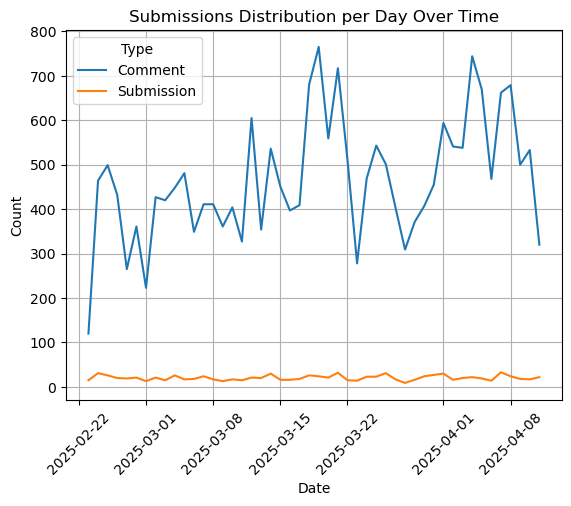

In [143]:
# Submissions distribution per day
df_combined['date'] = df_combined['timestamp'].dt.date
df_day = df_combined.groupby(['date', 'type']).size().unstack(fill_value=0)
df_day.plot(kind='line')
plt.title('Submissions Distribution per Day Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.grid(True)

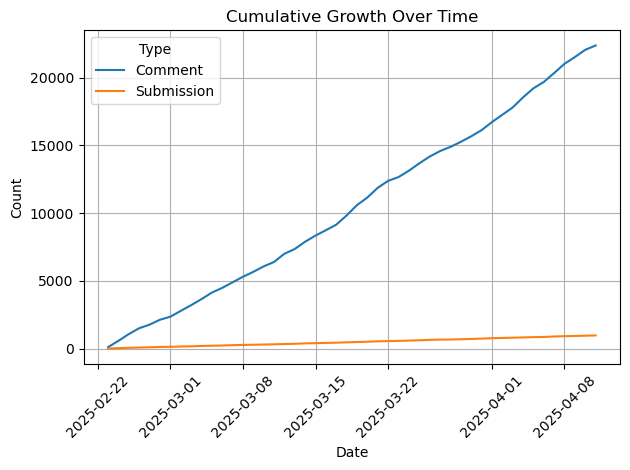

In [144]:
# Cumulative Growth
df_combined['date'] = df_combined['timestamp'].dt.date # new column for date
cumulative = df_combined.groupby(['date', 'type']).size().unstack(fill_value=0).cumsum()
cumulative.plot(kind='line')
plt.title('Cumulative Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.grid(True)

plt.tight_layout()
plt.show()

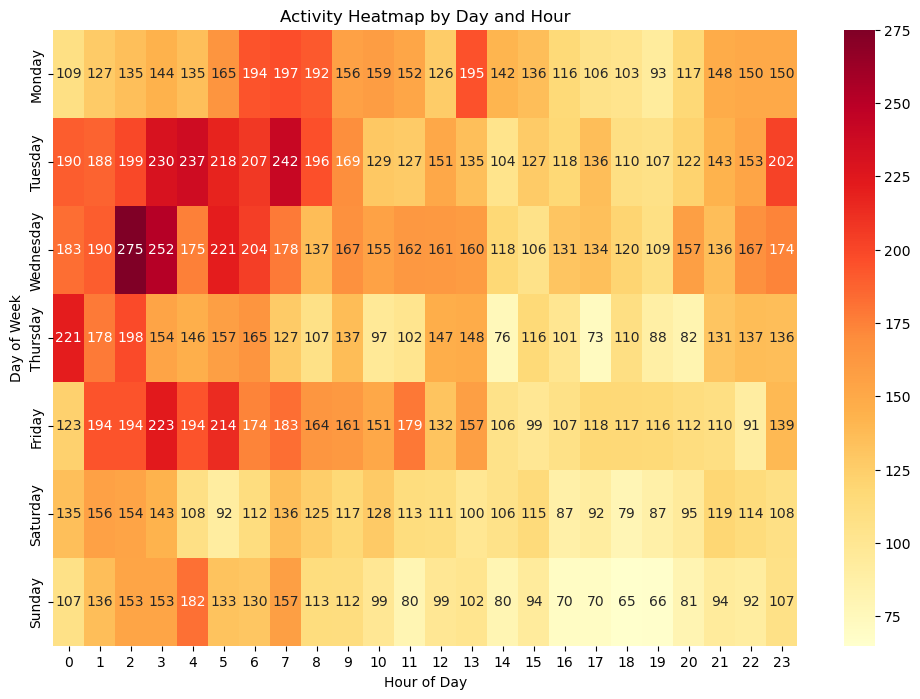

In [165]:
# Heatmap of Activity
plt.figure(figsize=(12, 8))
df_combined['hour'] = df_combined['timestamp'].dt.hour # new column for hour of day
df_combined['day_of_week'] = df_combined['timestamp'].dt.day_name() # new column for day of week

# Define the day order 
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df_combined.groupby(['day_of_week', 'hour']).size().unstack()
heatmap_data = heatmap_data.reindex(day_order) 
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g')
plt.title('Activity Heatmap by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

# Text Preprocessing

In [146]:
# Define tokenizer
tweetTokenizer = TweetTokenizer()

# Build punctuation list and stopwords list
lPunct = list(string.punctuation)
lStopwords = stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`', '’','@']

# Create a stemmer instance
stemmer = PorterStemmer()

# Call the RedditProcess python script
redditProcessor = RedditProcess(tweetTokenizer, lStopwords, stemmer)

# Create an empty list to store tokens after text preprocessing
TokensData = []

# Perform text preprocessing for submissions and comments
for submission in SubredditData['submissions']:
    submissionsTitle = submission.get('title', '')
    lTokens = redditProcessor.process(submissionsTitle)  # Process title
    TokensData.append(lTokens) 

    submissionsContent = submission.get('content', '')
    if submissionsContent:
        lTokens = redditProcessor.process(submissionsContent)  # Process content
        TokensData.append(lTokens)
    
    comments = submission.get('comments', [])
    for comment in comments:
        comment_text = comment.get('text', '')
        if comment_text:
            lTokens = redditProcessor.process(comment_text)  # Process comment
            TokensData.append(lTokens)


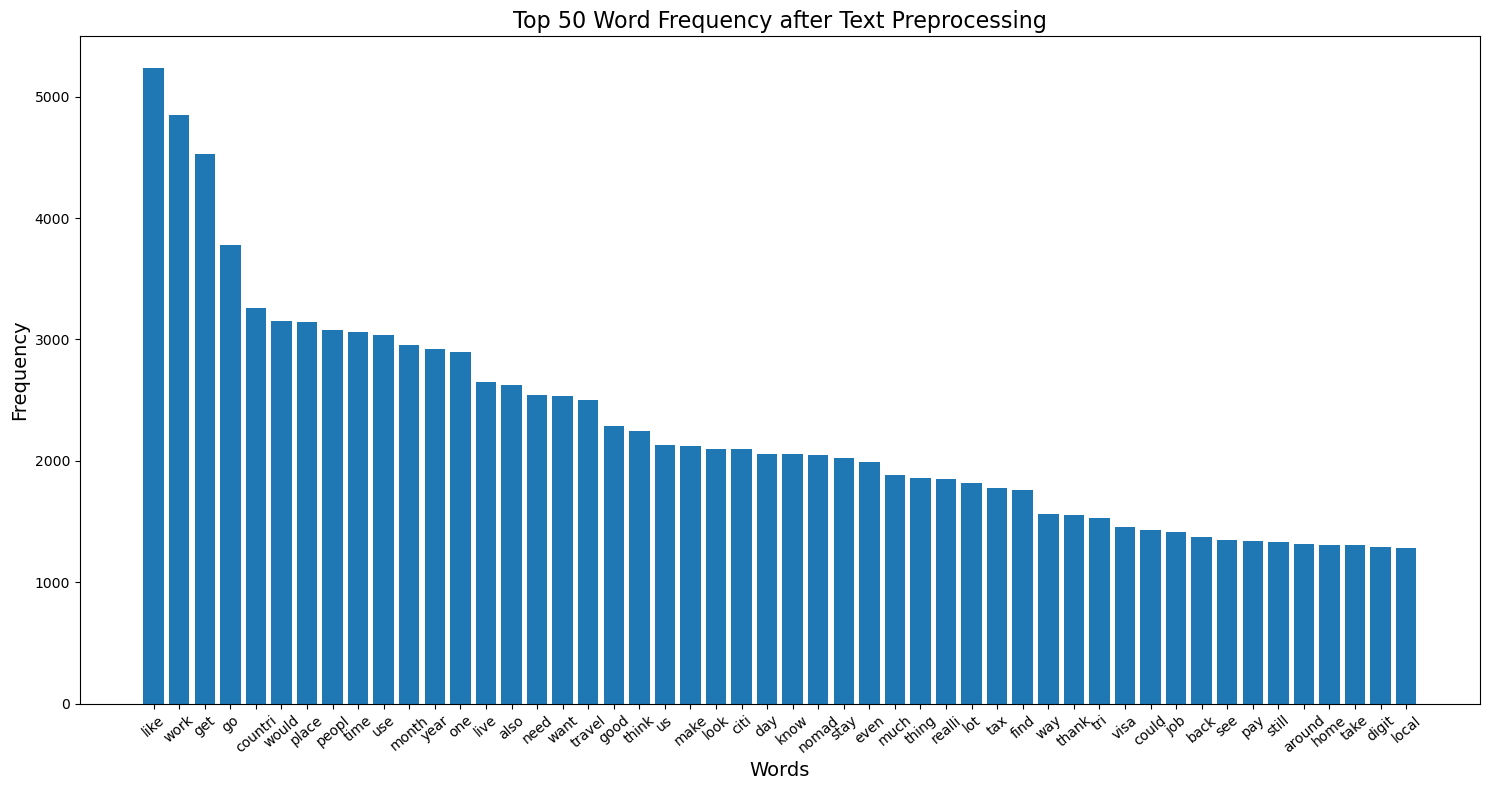

In [148]:
# Count frequencies of each token
token_counts = Counter()
for token_list in TokensData:
    token_counts.update(token_list)

# Get the 50 most common terms
top_50 = token_counts.most_common(50)

# Split into terms and counts
terms, counts = zip(*top_50)

# Plot
plt.figure(figsize=(15, 8))
plt.bar(terms, counts)
plt.xticks(rotation=40)
plt.xlabel('Words',fontsize = 14)
plt.ylabel('Frequency', fontsize = 14)
plt.title('Top 50 Word Frequency after Text Preprocessing', fontsize = 16)
plt.tight_layout()
plt.show()

# LDA model

### Reference: Codes below are from COSC2671 Social Media and Network Analytics Workshop 6, created by Jeffrey Chan, RMIT University, 2023.

In [149]:
import numpy as np
import math
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [151]:
#
# LDA parameters
#

# number of topics to discover (default = 10)
topicNum = 6
# maximum number of words to display per topic (default = 10)
# Answer to Exercise 1 (change from 10 to 15)
wordNumToDisplay = 15
# this is the number of features/words to used to describe our documents
featureNum = 2300

In [152]:
lPosts = []

# Loop through each list of tokens (each submission and comment)
for single_submission_tokens in TokensData:
    post_string = ' '.join(single_submission_tokens)
    lPosts.append(post_string)  # Append the resulting string for this submission to lPosts

In [153]:
#
# Count Vectorizer
#
# Transforms text into a sparse matrix of n-gram counts.
tfVectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform(lPosts)


# extract the names of the features (in our case, the words)
tfFeatureNames = tfVectorizer.get_feature_names_out()

#
# LDA MODEL
#

# Run LDA (see documentation about what the arguments means)
ldaModel = LatentDirichletAllocation(n_components = topicNum, max_iter=10, learning_method='online').fit(tf)

In [154]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# # Convert a collection of raw documents to a matrix of TF-IDF features.

# Tfidvectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
# Tfid = Tfidvectorizer.fit_transform(lPosts)

# TfidFeatureNames = Tfidvectorizer.get_feature_names_out()

# ldaModel = LatentDirichletAllocation(n_components = topicNum, max_iter=10, learning_method='online').fit(Tfid)


In [155]:
def display_topics(model, featureNames, numTopWords):
    """
    Prints out and returns the most associated words for each topic.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    @param numTopWords: number of words to print per topic.
    @return: list of strings, each representing a topic and its top words.
    """
    topic_list = []
    for topicId, lTopicDist in enumerate(model.components_):
        Id = "Topic %d:" % (topicId)
        words = " ".join([featureNames[i] for i in lTopicDist.argsort()[:-numTopWords - 1:-1]])
        topic_str = f"{Id} {words}"  
        print(topic_str)
        topic_list.append(topic_str) # To save the topic and its top words
    return topic_list
                

### pyLDAvis

In [157]:
panel = pyLDAvis.lda_model.prepare(ldaModel, tf, tfVectorizer, mds='tsne', n_jobs=1)
pyLDAvis.display(panel)

In [158]:
pyLDAvis.save_html(panel, fileobj="output.html")

### Wordcloud

In [159]:
def displayWordcloud(model, featureNames):
    """
    Displays the word cloud of the topic distributions, stored in model.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    """

    # this normalises each row/topic to sum to one
    # use this normalisedComponents to display your wordclouds
    normalisedComponents = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]

    # TODO: complete the implementation

    topicNum = len(model.components_)
    # number of wordclouds for each row
    plotColNum = 3
    # number of wordclouds for each column
    plotRowNum = int(math.ceil(topicNum / plotColNum))

    for topicId, lTopicDist in enumerate(normalisedComponents):
        lWordProb = {featureNames[i] : wordProb for i,wordProb in enumerate(lTopicDist)}
        wordcloud = WordCloud(background_color='black')
        wordcloud.fit_words(frequencies=lWordProb)
        plt.subplot(plotRowNum, plotColNum, topicId+1)
        plt.title('Topic %d:' % (topicId+1))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.tight_layout(rect=[0, 0.03, 2, 1.5])
        plt.axis("off")

    plt.show(block=True)

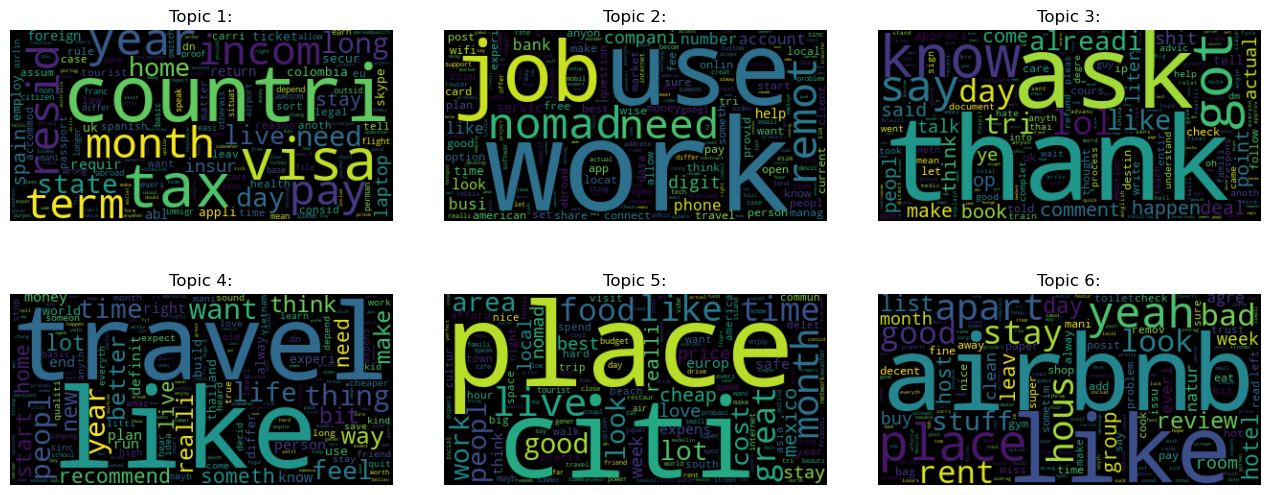

In [160]:
displayWordcloud(ldaModel, tfFeatureNames)